# Topological Sort

**Domain:** `data-structures-algorithms`

Picture a college course-prerequisite chart: *Intro to CS* must come before
*Data Structures*, which must come before *Algorithms*, which must come
before *Capstone*. You can't just take these in any order — enrollment
literally blocks you if a prerequisite isn't done. But within those rules,
there's often *more than one* valid order: maybe you take *Data Structures*
right after *Intro*, or you squeeze in an elective first. Any order that
never puts a course before its prerequisite works.

Or simpler: getting dressed. Socks before shoes. Shirt before jacket.
Underwear before pants. Nobody hands you a single mandatory sequence for
"getting dressed" — you could put your socks on before or after your
shirt, it doesn't matter — but *some* pairs are locked: shoes always come
after socks, no exceptions.

That's the whole problem **topological sort** solves: given a bunch of
tasks and a set of "this must happen before that" rules, produce *one
valid overall order* that respects every rule. Not *the* order — *a*
valid order, because usually several exist.

By the end of this tutorial you'll be able to: explain both classic
algorithms for computing a topological order (Kahn's algorithm and a
DFS-based method), prove exactly when a valid order exists at all, derive
why both run in $O(V+E)$ time, and run a real, compiled Java
implementation that detects cycles and reports timing on real graphs.

## The idea, intuitively

**Model the tasks as a graph.** Each task is a **node**. Draw a directed
**edge A &rarr; B** to mean "A must happen before B." A topological order
is then just: **list every node in a line such that every edge points
forward** — from something earlier in the line to something later.

This only makes sense if the graph has no cycles (more on that in the next
section) — a graph like this is called a **DAG**, a **Directed Acyclic
Graph**. There are two classic ways to compute a valid order:

**1. Kahn's algorithm** (in-degree removal): a node's **in-degree** is how
many unfinished prerequisites still point at it. Repeat: find a node with
in-degree zero (nothing left blocking it), add it to the order, "remove"
it from the graph, and decrement the in-degree of everything it pointed
at. Keep going until every node is placed.

**2. DFS-based**: run a **depth-first search** from every node, and record
the order in which nodes *finish* (i.e., when you're fully done exploring
everything reachable from that node). Reverse that finishing order — that
reversed list is a valid topological order. (This tutorial's
[depth-first-search tutorial](../depth-first-search/) covers DFS itself in
depth; here we build directly on the discover/finish-time idea.)

### A tiny hand-traced example

A simplified course chart, 6 nodes:

```
Intro -> Data101
Intro -> Algo201
Data101 -> Algo201
Data101 -> Systems301
Algo201 -> Capstone401
Systems301 -> Capstone401
```

Read as: `Intro` must come before `Data101`, `Intro` must come before
`Algo201`, and so on.

**Walking through Kahn's algorithm:**

| Step | In-degree-0 nodes available | Pick | Order so far |
|---|---|---|---|
| 1 | `Intro` | `Intro` | `Intro` |
| 2 | `Data101` | `Data101` | `Intro, Data101` |
| 3 | `Algo201`, `Systems301` (tie!) | `Algo201` | `Intro, Data101, Algo201` |
| 4 | `Systems301` | `Systems301` | `Intro, Data101, Algo201, Systems301` |
| 5 | `Capstone401` | `Capstone401` | `Intro, Data101, Algo201, Systems301, Capstone401` |

Notice **step 3**: both `Algo201` and `Systems301` had in-degree zero at
the same time. Either choice is valid — this is exactly why topological
order is generally **not unique**. Picking `Systems301` first there would
give an equally-valid order `Intro, Data101, Systems301, Algo201,
Capstone401`.

Here's the core of that step as real, tiny Python — computing in-degrees
on a toy adjacency dict, and doing one removal:

In [1]:
# Toy adjacency structure: node -> list of nodes it points to (prerequisites -> dependents)
adjacency = {
    "Intro": ["Data101", "Algo201"],
    "Data101": ["Algo201", "Systems301"],
    "Algo201": ["Capstone401"],
    "Systems301": ["Capstone401"],
    "Capstone401": [],
}

# Compute in-degree of every node: how many edges point AT it.
in_degree = {node: 0 for node in adjacency}
for node, neighbors in adjacency.items():
    for neighbor in neighbors:
        in_degree[neighbor] += 1

print("in-degrees:", in_degree)

# One removal step: find a node with in-degree 0, "remove" it, update its neighbors.
ready = [n for n, d in in_degree.items() if d == 0]
print("in-degree-0 nodes right now:", ready)

node = ready[0]
order = [node]
for neighbor in adjacency[node]:
    in_degree[neighbor] -= 1
print(f"removed {node!r}; order so far: {order}; updated in-degrees: {in_degree}")

in-degrees: {'Intro': 0, 'Data101': 1, 'Algo201': 2, 'Systems301': 1, 'Capstone401': 2}
in-degree-0 nodes right now: ['Intro']
removed 'Intro'; order so far: ['Intro']; updated in-degrees: {'Intro': 0, 'Data101': 0, 'Algo201': 1, 'Systems301': 1, 'Capstone401': 2}


**Takeaway:** a node can only be added to the order once *every*
edge pointing at it has already been "used up" — which is exactly what
"in-degree reaches zero" tracks. Repeating this removal step until no
nodes remain is the entirety of Kahn's algorithm; the full Java
implementation later in this tutorial is this same loop, just with real
timing and cycle detection added.

## Going deeper: the formal definition

### DAGs and topological order, formally

A **directed graph** $G = (V, E)$ consists of a set of vertices $V$ and a
set of directed edges $E \subseteq V \times V$, where edge $(u, v) \in E$
means "$u$ must precede $v$." $G$ is a **DAG (Directed Acyclic Graph)** if
it contains no directed cycle — no sequence of edges
$v_1 \to v_2 \to \cdots \to v_k \to v_1$ for $k \ge 1$.

A **topological order** of $G$ is a total order (a linear sequence)
$v_1, v_2, \ldots, v_n$ of $V$ such that for every edge $(v_i, v_j) \in E$,
$i < j$ — every edge points from an earlier position to a later one.

### A topological order exists if and only if $G$ is a DAG

**($\Rightarrow$) If a cycle exists, no topological order exists.**
Suppose $v_1 \to v_2 \to \cdots \to v_k \to v_1$ is a cycle, and suppose
for contradiction a topological order placed these nodes at positions
$p_1, \ldots, p_k$. Every edge $v_i \to v_{i+1}$ forces $p_i < p_{i+1}$, so
$p_1 < p_2 < \cdots < p_k$. But the edge $v_k \to v_1$ also forces
$p_k < p_1$. Combined with $p_1 < p_k$, this gives $p_1 < p_1$ — a
contradiction. So no valid order can exist when a cycle is present;
intuitively, some node on the cycle would need to come "before itself."

**($\Leftarrow$) If $G$ is acyclic, Kahn's algorithm always succeeds.**
Claim: in any nonempty DAG, at least one node has in-degree zero. If
every node had in-degree $\ge 1$, start at any node and repeatedly walk
backward along an incoming edge; since $V$ is finite, this walk must
revisit some node, producing a cycle — contradicting acyclicity. So a
DAG always has an in-degree-zero node to remove.

Removing a node and its outgoing edges from a DAG leaves a smaller DAG
(removing nodes/edges cannot create a cycle that wasn't already there).
By induction on $|V|$: the base case $|V| = 0$ is trivially orderable, and
the inductive step removes one in-degree-zero node (which is safe to place
first, since nothing in the remaining graph needs to precede it) and
applies the inductive hypothesis to the rest. So Kahn's algorithm never
gets stuck on an acyclic graph, and always terminates with all $n$ nodes
placed. $\blacksquare$

Equivalently: **Kahn's algorithm terminates with fewer than $n$ nodes
placed if and only if a cycle exists** — this is precisely how the
implementation below detects cycles, and every node left over with
nonzero in-degree is part of (or downstream of) that cycle.

### Complexity: $O(V + E)$ for both methods

**Kahn's algorithm:** computing every node's initial in-degree is one pass
over all edges, $O(E)$. Each node is pushed onto the "ready" structure and
popped exactly once, $O(V)$ pushes/pops. Each edge is examined exactly
once, when its source node is removed, to decrement the target's
in-degree, $O(E)$. Total: $O(V + E)$ (using an $O(1)$-amortized ready
queue; a priority-queue tie-breaker, as used for the multiple-orders demo
below, adds a $\log V$ factor, giving $O(E + V\log V)$).

**DFS-based:** standard DFS visits every node once, $O(V)$, and examines
every edge exactly once (from its source node), $O(E)$. Recording a
finishing time and reversing the resulting list at the end is $O(V)$. Total:
$O(V + E)$.

### The DFS method, formally: why reverse-finish-time order works

Standard DFS (CLRS Ch. 22) assigns each node a **discovery time** $d[v]$
(when DFS first visits it) and a **finish time** $f[v]$ (when DFS is fully
done exploring everything reachable from it — i.e., its recursive call
returns). Every node's interval $[d[v], f[v]]$ is either nested inside or
entirely disjoint from any other node's interval (the *parenthesis
theorem*).

**Claim:** for every edge $u \to v$ in a DAG, $f[v] < f[u]$ — the source
of an edge always finishes *after* its target.

**Proof:** DFS visiting the edge $u \to v$ hits one of three cases:

- $v$ is undiscovered: DFS recurses into $v$ immediately, and by the
  structure of recursion, $v$'s entire visit (discovery through finish)
  is nested inside $u$'s, so $f[v] < f[u]$.
- $v$ is discovered but not finished (it's an ancestor of $u$ on the
  current DFS stack): this would mean edge $u \to v$ points back to an
  active ancestor — a **back edge**, which only occurs if the graph has a
  cycle. Excluded, since $G$ is a DAG.
- $v$ is already finished: $v$'s interval already closed before $u$'s
  did, so $f[v] < f[u]$ trivially (intervals can't overlap without
  nesting).

In every case consistent with acyclicity, $f[v] < f[u]$. $\blacksquare$

So for every edge $u \to v$: $f[u] > f[v]$, meaning **sorting nodes by
*decreasing* finish time places $u$ before $v$ for every edge** — which is
exactly the definition of a valid topological order. That's why "reverse
of finishing-time order" works: a node only finishes once every task
reachable from it (everything it depends on being explored first) has
already finished, so it must land before its dependents once you reverse.

## Visuals

Let's draw an actual DAG and lay it out so the topological structure is
visible — prerequisites to the left, dependents to the right — using a
computed order **from the real compiled Java program** (built in the
Implementation section below; we compile it once here so these visuals use
genuine program output, not a Python re-implementation).

In [2]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
class_file = src_dir / "TopologicalSort.class"

compile_cmd = ["javac", str(src_dir / "TopologicalSort.java")]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", class_file)

compile return code: 0
compiled successfully -> src\TopologicalSort.class


In [3]:
def run_topo_sort(edges, tie_break="asc"):
    # Run the real compiled TopologicalSort.java on an edge list, return parsed results.
    input_str = "\n".join(f"{a} {b}" for a, b in edges)
    proc = subprocess.run(
        ["java", "-cp", str(src_dir), "TopologicalSort", tie_break],
        input=input_str, capture_output=True, text=True,
    )
    assert proc.returncode == 0, proc.stderr
    out = {"raw": proc.stdout}
    lines = proc.stdout.strip().splitlines()
    i = 0
    while i < len(lines):
        line = lines[i]
        if line.startswith("n="):
            out["n"] = int(line.split("=")[1])
        elif line.startswith("e="):
            out["e"] = int(line.split("=")[1])
        elif line in ("kahn:", "dfs:"):
            method = line[:-1]
            i += 1
            detail = lines[i]
            if "CYCLE DETECTED" in detail:
                i += 1
                nodes_line = lines[i]
                out[method] = {"cycle": True, "nodes": nodes_line.split(":", 1)[1].strip()}
            else:
                order_str = detail.split(":", 1)[1].strip()
                order = order_str.strip("[]").split(", ") if order_str != "[]" else []
                out[method] = {"cycle": False, "order": order}
            i += 1
            time_line = lines[i]
            out[method]["micros"] = int(time_line.split("=")[1])
        i += 1
    return out

course_edges = [
    ("Intro", "Data101"),
    ("Intro", "Algo201"),
    ("Data101", "Algo201"),
    ("Data101", "Systems301"),
    ("Algo201", "Capstone401"),
    ("Systems301", "Capstone401"),
]

result_asc = run_topo_sort(course_edges, tie_break="asc")
print(result_asc["raw"])

n=5
e=6
kahn:
  order: [Intro, Data101, Algo201, Systems301, Capstone401]
  time_micros=11743
dfs:
  order: [Intro, Data101, Systems301, Algo201, Capstone401]
  time_micros=405



### Multiple valid orders for the same DAG

Notice above: `Algo201` and `Systems301` were both ready (in-degree zero)
at the same step, just like in the hand-traced example. The compiled
program's **tie-breaking rule** for Kahn's algorithm is a command-line
argument (`asc` vs `desc`, alphabetical order of which ready node to pick
next). Let's run the *same* graph twice, with the tie-break flipped, and
confirm we get **two different — but both valid — topological orders**:

In [4]:
result_desc = run_topo_sort(course_edges, tie_break="desc")

order_asc = result_asc["kahn"]["order"]
order_desc = result_desc["kahn"]["order"]

print("Kahn's algorithm, ascending tie-break: ", order_asc)
print("Kahn's algorithm, descending tie-break:", order_desc)
print()
print("Different orders?", order_asc != order_desc)


def is_valid_topo_order(order, edges):
    position = {node: i for i, node in enumerate(order)}
    return all(position[a] < position[b] for a, b in edges)


print("ascending order respects every edge: ", is_valid_topo_order(order_asc, course_edges))
print("descending order respects every edge:", is_valid_topo_order(order_desc, course_edges))

Kahn's algorithm, ascending tie-break:  ['Intro', 'Data101', 'Algo201', 'Systems301', 'Capstone401']
Kahn's algorithm, descending tie-break: ['Intro', 'Data101', 'Systems301', 'Algo201', 'Capstone401']

Different orders? True
ascending order respects every edge:  True
descending order respects every edge: True


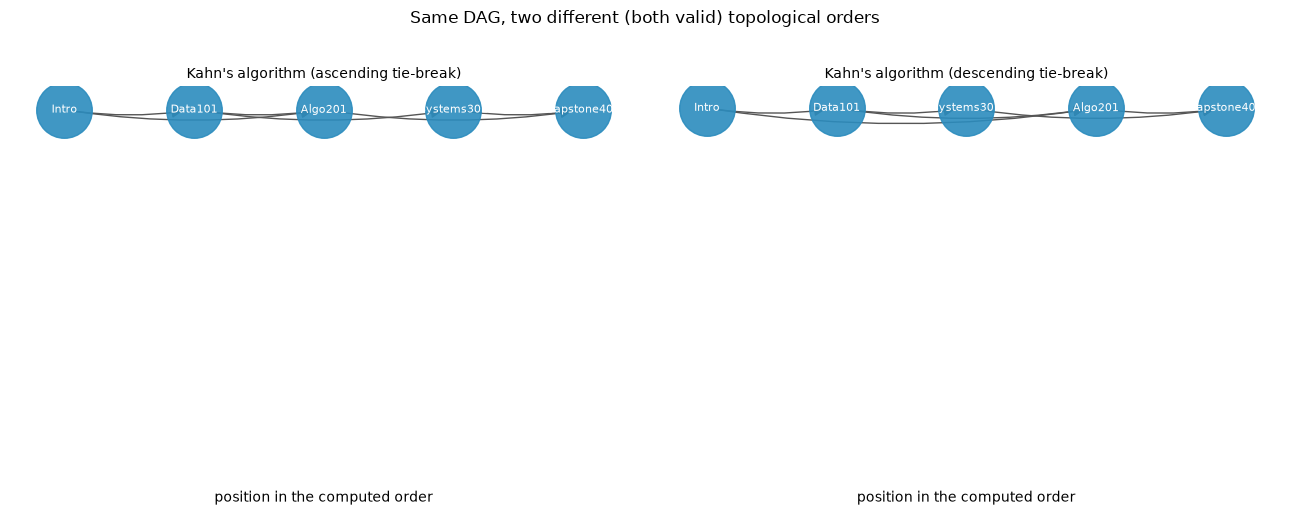

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
G.add_edges_from(course_edges)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, order, title in zip(
    axes,
    [order_asc, order_desc],
    ["Kahn's algorithm (ascending tie-break)", "Kahn's algorithm (descending tie-break)"],
):
    # Layered layout: x = position in this particular topological order,
    # y = a small stagger so parallel nodes don't overlap.
    position_index = {node: i for i, node in enumerate(order)}
    pos = {}
    y_stagger = {0: 0.4, 1: -0.4, 2: 0.0}
    seen_at_x = {}
    for node in order:
        x = position_index[node]
        seen_at_x.setdefault(x, 0)
        pos[node] = (x, y_stagger.get(seen_at_x[x], 0.0))
        seen_at_x[x] += 1

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#2b8cbe", node_size=1600, alpha=0.9)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color="white", font_size=8)
    nx.draw_networkx_edges(
        G, pos, ax=ax, arrowstyle="-|>", arrowsize=15, edge_color="#555555",
        connectionstyle="arc3,rad=0.08",
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("position in the computed order")
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle("Same DAG, two different (both valid) topological orders", y=1.02)
plt.tight_layout()
plt.savefig("topo_orders_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

Both layouts respect every arrow (every edge points left-to-right,
never backward) — neither order is "more correct" than the other. This is
the non-uniqueness point made visible: **"a valid order," not "the"
order.**

### Runtime vs. graph size

The complexity argument above claims both methods run in $O(V+E)$ — linear
in the graph's total size. Let's generate layered random DAGs of
increasing size and confirm real, measured timings from the compiled
program track that prediction.

In [6]:
import random

random.seed(11)


def random_layered_dag(num_layers, nodes_per_layer, edge_prob=0.3):
    # Build a DAG by layers: every edge only goes from an earlier layer to
    # a later layer, which guarantees acyclicity by construction.
    edges = []
    layers = [[f"L{layer}_{i}" for i in range(nodes_per_layer)] for layer in range(num_layers)]
    for li in range(num_layers - 1):
        for u in layers[li]:
            for v in layers[li + 1]:
                if random.random() < edge_prob:
                    edges.append((u, v))
    # Guarantee every node in an interior layer has at least one edge in and out,
    # so isolated nodes don't shrink E to near-zero.
    for li in range(num_layers - 1):
        for u in layers[li]:
            if not any(e[0] == u for e in edges):
                edges.append((u, random.choice(layers[li + 1])))
    return edges


graph_sizes = []
kahn_times = []
dfs_times = []

for num_layers, nodes_per_layer in [(3, 5), (5, 8), (8, 12), (12, 16), (16, 20), (20, 25), (25, 30)]:
    edges = random_layered_dag(num_layers, nodes_per_layer, edge_prob=0.25)
    nodes = {n for e in edges for n in e}
    result = run_topo_sort(edges)
    v_plus_e = result["n"] + result["e"]
    graph_sizes.append(v_plus_e)
    kahn_times.append(result["kahn"]["micros"])
    dfs_times.append(result["dfs"]["micros"])
    print(f"V={result['n']:4d}  E={result['e']:5d}  V+E={v_plus_e:5d}  "
          f"kahn={result['kahn']['micros']:6d}us  dfs={result['dfs']['micros']:6d}us")

V=  13  E=   16  V+E=   29  kahn= 10957us  dfs=   587us


V=  39  E=   70  V+E=  109  kahn= 13614us  dfs=   825us


V=  96  E=  250  V+E=  346  kahn= 15260us  dfs=  1030us


V= 192  E=  699  V+E=  891  kahn= 14141us  dfs=  2635us


V= 320  E= 1537  V+E= 1857  kahn= 22189us  dfs=  4672us


V= 500  E= 2900  V+E= 3400  kahn= 25258us  dfs=  5671us


V= 750  E= 5335  V+E= 6085  kahn= 36083us  dfs=  9275us


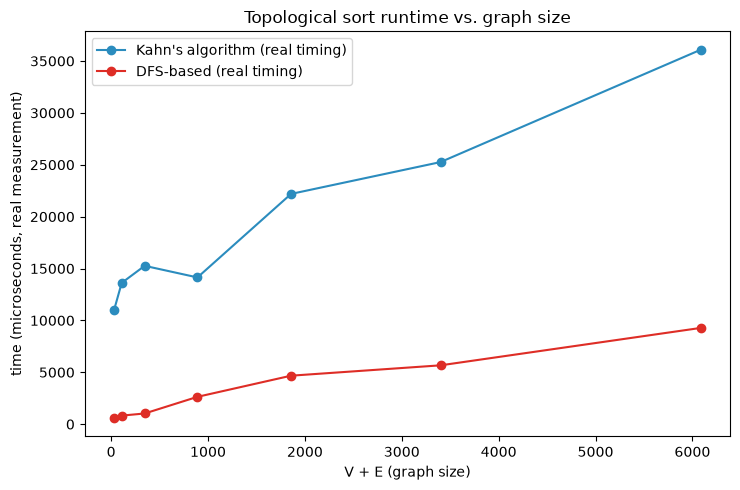


Note: at these small sizes, JIT warm-up and OS scheduling noise dominate
the microsecond-scale timings more than the O(V+E) trend itself -- the
trend becomes visually clean once graphs get into the thousands of nodes.


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(graph_sizes, kahn_times, "o-", label="Kahn's algorithm (real timing)", color="#2b8cbe")
ax.plot(graph_sizes, dfs_times, "o-", label="DFS-based (real timing)", color="#de2d26")
ax.set_xlabel("V + E (graph size)")
ax.set_ylabel("time (microseconds, real measurement)")
ax.set_title("Topological sort runtime vs. graph size")
ax.legend()
plt.tight_layout()
plt.savefig("runtime_vs_size.png", dpi=110)
plt.show()

print("\nNote: at these small sizes, JIT warm-up and OS scheduling noise dominate")
print("the microsecond-scale timings more than the O(V+E) trend itself -- the")
print("trend becomes visually clean once graphs get into the thousands of nodes.")

## Implementation

The reference implementation lives in
[`src/TopologicalSort.java`](src/TopologicalSort.java) — real Java,
implementing **both** Kahn's algorithm and the DFS-based method, each with
explicit **cycle detection** (rather than silently returning a partial or
wrong order), and each instrumented to time itself with
`System.nanoTime()`.

It reads a directed edge list from stdin (`A B` meaning "A before B") and
prints:

- `n=` / `e=` — the parsed graph's node and edge counts
- `kahn:` — Kahn's algorithm's order, or `CYCLE DETECTED` plus every node
  stuck in (or downstream of) the cycle
- `dfs:` — the DFS-based method's order, or the same cycle report
- `time_micros=` for each method

We already compiled it above (needed for the visuals); here we exercise
the **cycle-detection path specifically** — a graph that is *not* a valid
DAG, where no topological order can exist.

In [8]:
cyclic_edges = [
    ("A", "B"),
    ("B", "C"),
    ("C", "A"),   # closes the cycle A -> B -> C -> A
    ("X", "Y"),   # a separate, unrelated, perfectly orderable pair
]

cyclic_result = run_topo_sort(cyclic_edges)
print(cyclic_result["raw"])

n=5
e=4
kahn:
  CYCLE DETECTED - no valid topological order exists
  nodes involved in/blocked by cycle: [A, B, C]
  time_micros=10820
dfs:
  CYCLE DETECTED - no valid topological order exists
  nodes involved in/blocked by cycle: [A, B, C]
  time_micros=207



Both methods correctly report `CYCLE DETECTED` rather than silently
producing a wrong or partial order. Notice **Kahn's algorithm's cycle
report names exactly `A`, `B`, `C`** — the nodes actually stuck on the
cycle — while correctly leaving `X` and `Y` out, since that pair is fine
on its own. This is a genuinely useful debugging property: Kahn's
algorithm's leftover-nonzero-in-degree set tells you *which* nodes are
the problem, not just *that* there's a problem — see Limitations &
debates below for why this matters in practice.

## Use cases

- **Build systems**: Make, Bazel, and similar tools compute a compile order
  from a dependency graph of targets/object files — a `.o` file's rule
  can't run until every header/source it depends on is ready. A cyclic
  `Makefile` dependency is a real, commonly-hit build error.
- **Package manager dependency resolution**: `npm install` and `pip
  install` must install a package's dependencies before the package
  itself. Both ecosystems have hit real, reported **circular dependency**
  bugs where package A depends on B which (transitively) depends on A —
  exactly the case this tutorial's cycle detection guards against.
- **Build tool dependency graphs**: Maven and Gradle resolve a project's
  module/dependency graph topologically to decide compile order across
  multi-module projects; a circular module dependency is a build-breaking
  error these tools explicitly detect and report.
- **Task scheduling with prerequisites**: course scheduling (this
  tutorial's running example), and project-management tools computing a
  valid task execution order from a dependency chart — related to, but
  simpler than, critical-path-method scheduling, which additionally
  weighs tasks by duration.
- **Spreadsheet formula recalculation order**: if cell `C1` contains
  `=A1+B1`, the spreadsheet engine must recompute `A1` and `B1` before
  `C1`. Excel and Google Sheets build a dependency graph of cell
  references and topologically order recalculation — and both explicitly
  detect and report **circular references** (e.g. `A1` referencing `B1`
  which references `A1`) rather than looping forever or silently using a
  stale value.

## Limitations & debates

- **Only defined for DAGs — a cycle means no valid order exists, full
  stop.** This isn't a corner case to shrug off: it's a common real-world
  failure mode. Undetected circular dependencies in build systems and
  package managers are a well-documented, recurring class of bug — a tool
  that doesn't explicitly check for cycles can loop forever, crash, or
  (worse) silently produce *some* order that violates a dependency and
  ships broken output. The implementation here treats cycle detection as
  a first-class, required output, not an afterthought.
- **The result is not unique, and code that depends on a *specific*
  order (rather than *some valid* order) is fragile.** The visuals above
  demonstrated this directly: the same DAG produced two different, both
  correct, orders under different tie-breaking rules. Any downstream code
  that accidentally relies on, say, "package A always installs before
  package C" when the *only* guarantee is "A installs before B, which
  installs before C" is relying on an implementation detail that a future
  tie-breaking change (or a different library, or a different language's
  standard sort stability) can silently break.
- **Kahn's algorithm vs. the DFS-based method is a real, practical
  tradeoff, not just "two ways to do the same thing."** Kahn's algorithm
  naturally reveals *every* node stuck in a cycle as a side effect of the
  normal termination check (see the Implementation section's cyclic-graph
  demo) — a genuinely useful debugging property when you need to tell a
  user *why* their build/dependency graph is broken. The DFS-based method
  detects *that* a cycle exists (via a back edge) but does not, without
  extra bookkeeping, hand you the full set of implicated nodes as
  directly. On the other hand, DFS-based topological sort composes
  naturally with other DFS-based graph algorithms (e.g. strongly-connected
  components via Tarjan's or Kosaraju's algorithms) if you're already
  running DFS for another reason.
- **Both methods are $O(V+E)$, so asymptotic complexity is rarely the
  deciding factor** in choosing one — the choice in practice usually comes
  down to which debugging information you need, and whether you're
  already running DFS for something else in the same codebase.

## References

- Kahn, A. B. *Topological Sorting of Large Networks*, Communications of
  the ACM, 1962 (the original algorithm, Kahn's algorithm's namesake).
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  Chapter 22 — the DFS-based topological sort algorithm, the
  discover/finish-time framework, and its correctness proof, which this
  tutorial's "Going deeper" section follows.
- `src/TopologicalSort.java` in this tutorial's folder — the real,
  compiled implementation used for every measurement and demonstration
  above.